# VIV Data Prep (Neural CDE + SHRED)

Clean data loading and preparation with ready-to-use datasets.

## Imports and paths

In [1]:
import sys
from pathlib import Path

import numpy as np

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import importlib
import scripts.animations
importlib.reload(scripts.animations)
from scripts.data_prep import *
from scripts.animations import *

In [2]:
import mlflow
from scripts.mlflow_utils import *

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
csv_dir = project_root / 'NDP38m_extracted_csv'
lag = 10
nsensors = 3
modes_cf = 10
modes_il = 15
seed = 42
stride = 5
n_trajectories = None  #NOTE If not None then the splitting will be sequential, with None it is random over the whole domain.

# Load all available CF/IL pairs (sorted by riser speed: 2040, 2100, 2160, 2220)
pairs = load_csv_pairs(csv_dir)
if not pairs:
    raise FileNotFoundError(f'No CF/IL pairs found in {csv_dir}')

print(f"Found {len(pairs)} CF/IL pairs:")
for i, (cf, il) in enumerate(pairs):
    print(f"  [{i}] {cf.name}  |  {il.name}")

# Stack all pairs EXCEPT the last one for training
# Hold out the last pair (highest riser speed) for generalisation testing
train_pairs = pairs[:-1]
test_pair = pairs[-1]

print(f"\nTraining pairs ({len(train_pairs)}):")
for cf, il in train_pairs:
    print(f"  {cf.name}  |  {il.name}")
print(f"Held-out test pair: {test_pair[0].name}  |  {test_pair[1].name}")

Found 4 CF/IL pairs:
  [0] DISPL2040_DISPLCF.csv  |  DISPL2040_DISPLIL.csv
  [1] DISPL2100_DISPLCF.csv  |  DISPL2100_DISPLIL.csv
  [2] DISPL2160_DISPLCF.csv  |  DISPL2160_DISPLIL.csv
  [3] DISPL2220_DISPLCF.csv  |  DISPL2220_DISPLIL.csv

Training pairs (3):
  DISPL2040_DISPLCF.csv  |  DISPL2040_DISPLIL.csv
  DISPL2100_DISPLCF.csv  |  DISPL2100_DISPLIL.csv
  DISPL2160_DISPLCF.csv  |  DISPL2160_DISPLIL.csv
Held-out test pair: DISPL2220_DISPLCF.csv  |  DISPL2220_DISPLIL.csv


In [4]:
# Initialize MLflow experiment
run_name, run_id = start_mlflow_run(
    experiment_name="VIV-Models",
    tags={"dataset": "VIV_NDP38m", "phase": "training_and_evaluation"},
    project_root=project_root,
)

MLflow run started: 2026-02-10_v13  (id=33b57cb3…)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


## Load and prepare stacked datasets 

In [5]:
datasets = prepare_stacked_viv_datasets(
    pairs=train_pairs,
    lag=lag,
    nsensors=nsensors,
    modes_cf=modes_cf,
    modes_il=modes_il,
    seed=seed,
    stride=stride,
)


print(f"\nSensor locations: {datasets['sensor_locations']}")
print(f"\nStacking summary:")
info = datasets['stacking_info']
for k, v in info.items():
    print(f"  {k}: {v}")

  Pair 1: DISPL2040_DISPLCF  →  6991 windows  (nt=7000, nx=200)
  Pair 2: DISPL2100_DISPLCF  →  4981 windows  (nt=4990, nx=200)
  Pair 3: DISPL2160_DISPLCF  →  2937 windows  (nt=2946, nx=200)
Stacked pool: 14909 total windows from 3 pairs
  Split → train=11927, valid=1490, test=1492
  POD CF: 10 modes → relative reconstruction error = 26.4468%
  POD IL: 15 modes → relative reconstruction error = 26.6702%

Sensor locations: [130, 17, 153, -1]

Stacking summary:
  pairs: ['DISPL2040_DISPLCF + DISPL2040_DISPLIL', 'DISPL2100_DISPLCF + DISPL2100_DISPLIL', 'DISPL2160_DISPLCF + DISPL2160_DISPLIL']
  pair_boundaries: [(0, 6991), (6991, 11972), (11972, 14909)]
  n_train_windows: 11927
  n_valid_windows: 1490
  n_test_windows: 1492


In [8]:

modes_cf = 10
modes_il = 15
test_pair = pairs[2]
datasets = prepare_viv_datasets_from_csv(
    cf_path = pairs[1][0], 
    il_path = pairs[1][1],
    lag = lag, 
    nsensors=nsensors,
    modes_cf=modes_cf,
    modes_il=modes_il,
    seed=seed,
    stride=stride,
)


Random split (legacy): train=3984, valid=498, test=499
  POD CF: 10 modes → relative reconstruction error = 7.2571%
  POD IL: 15 modes → relative reconstruction error = 8.6444%


In [9]:
# Log dataset configuration
log_dataset_params(
    csv_dir=csv_dir,
    pair_index="stacked",
    cf_path=str([p[0] for p in train_pairs]),
    il_path=str([p[1] for p in train_pairs]),
    lag=lag,
    nsensors=nsensors,
    modes_cf=modes_cf,
    modes_il=modes_il,
    seed=seed,
)

## Split overview (CDE + SHRED)

In [10]:
for split_name in ['train', 'valid', 'test']:
    cde_split = datasets['cde'][split_name]
    shred_split = datasets['shred'][split_name]
    print(f"CDE {split_name}: sensors {cde_split['sensors_raw'].shape} | pod_scaled {cde_split['pod_scaled'].shape}")
    print(f"SHRED {split_name}: sensors {shred_split['sensors_raw'].shape} | pod_scaled {shred_split['pod_scaled'].shape}")

CDE train: sensors (3984, 10, 6) | pod_scaled (3984, 25)
SHRED train: sensors (3984, 10, 6) | pod_scaled (3984, 25)
CDE valid: sensors (498, 10, 6) | pod_scaled (498, 25)
SHRED valid: sensors (498, 10, 6) | pod_scaled (498, 25)
CDE test: sensors (499, 10, 6) | pod_scaled (499, 25)
SHRED test: sensors (499, 10, 6) | pod_scaled (499, 25)


## Sequential dataset (original order)

In [11]:
cde_seq = datasets['cde']['sequential']
shred_seq = datasets['shred']['sequential']
print(f"CDE sequential sensors {cde_seq['sensors_raw'].shape} | pod_scaled {cde_seq['pod_scaled'].shape}")
print(f"SHRED sequential sensors {shred_seq['sensors_raw'].shape} | pod_scaled {shred_seq['pod_scaled'].shape}")

CDE sequential sensors (4981, 10, 6) | pod_scaled (4981, 25)
SHRED sequential sensors (4981, 10, 6) | pod_scaled (4981, 25)


In [12]:
cde_seq = datasets['cde']['sequential']
shred_seq = datasets['shred']['sequential']
print(f"CDE sequential sensors {cde_seq['sensors_raw'].shape} | pod_scaled {cde_seq['pod_scaled'].shape}")
print(f"SHRED sequential sensors {shred_seq['sensors_raw'].shape} | pod_scaled {shred_seq['pod_scaled'].shape}")

CDE sequential sensors (4981, 10, 6) | pod_scaled (4981, 25)
SHRED sequential sensors (4981, 10, 6) | pod_scaled (4981, 25)


### Train models

In [13]:
import importlib
import utils
importlib.reload(utils.models_diffrax)
from utils.models_diffrax import *

key = jr.PRNGKey(42)
model_key_1, model_key_2, loader_key = jr.split(key, 3)
hidden_size = 100
width_size = 64
depth = 2
output_size = datasets['cde']['train']['data']['Y'].shape[-1]
print(f"data size ={2*nsensors}, output_size={output_size}")
model_cde = NeuralCDE(2*nsensors, 
                    hidden_size, 
                    width_size, 
                    depth, 
                    activation_cde = jnn.tanh, 
                    activation_decoder = jnn.gelu, 
                    output_size = output_size, 
                    decoder_sizes= [350, 500], 
                    key=model_key_1)

print(datasets['cde']['train']['data']['coeffs'][0].shape, datasets['cde']['train']['data']['Y'].shape)



data size =6, output_size=25
(3984, 9, 6) (3984, 25)


In [14]:
# Log Neural CDE model architecture
log_cde_model_params(
    hidden_size=hidden_size,
    width_size=width_size,
    depth=depth,
    output_size=output_size,
    decoder_sizes=[350, 500],
)
log_model_architecture_info(model_cde, model_type="CDE")

## Train CDE Model

In [15]:
epochs = 100
lr = 1e-2
batch_size = 64 
patience = 10 

In [16]:
# Log CDE training hyperparameters
log_training_params(
    epochs=epochs,
    learning_rate=lr,
    batch_size=batch_size,  
    patience=patience,
    model_type="CDE",
)

# Train model
model_cde, train_losses_cde, valid_losses_cde = fit_CDE(model_cde, datasets['cde']['train']['data'], datasets['cde']['valid']['data'], epochs=epochs, batch_size=batch_size, lr=lr, early_stopping=patience)
model_cde, train_losses_cde_2, valid_losses_cde_2 = fit_CDE(model_cde, datasets['cde']['train']['data'], datasets['cde']['valid']['data'], epochs=epochs, batch_size=batch_size, lr=lr/10, early_stopping=patience)
model_cde, train_losses_cde_3, valid_losses_cde_3 = fit_CDE(model_cde, datasets['cde']['train']['data'], datasets['cde']['valid']['data'], epochs=epochs, batch_size=batch_size, lr=lr/100, early_stopping=patience)
train_losses_cde = train_losses_cde + train_losses_cde_2 + train_losses_cde_3
valid_losses_cde = valid_losses_cde + valid_losses_cde_2 + valid_losses_cde_3
# Log training metrics
log_training_metrics(train_losses_cde, valid_losses_cde, model_type="CDE")
log_loss_history_summary(train_losses_cde, valid_losses_cde, model_type="CDE")

Epoch 100/100 | Train 5.7819e-02 | Valid 7.8864e-02 | Time 2.41s | Patience 0/10
Training done: Train loss = 5.7819e-02 | Valid loss = 7.8864e-02
Epoch 100/100 | Train 6.5335e-03 | Valid 2.4227e-02 | Time 2.67s | Patience 0/1010
Training done: Train loss = 6.5335e-03 | Valid loss = 2.4227e-02
Epoch 100/100 | Train 2.9043e-03 | Valid 1.9836e-02 | Time 2.66s | Patience 1/10
Training done: Train loss = 2.9043e-03 | Valid loss = 1.9836e-02


## Train SHRED Model

In [17]:
from utils.models_diffrax import *
import importlib
import utils
importlib.reload(utils.models_diffrax)
from utils.models_diffrax import *

# SHRED: Use same data structure as Neural CDE for fair comparison
model_key_shred, = jr.split(jr.PRNGKey(0), 1)
output_size = datasets['shred']['train']['Y'].shape[-1]
print(f"data size ={2*nsensors}, output_size={output_size}")

model_shred = SHRED(2*nsensors, output_size, hidden_size=hidden_size, hidden_layers=depth, decoder_sizes=[350, 400], activation=jax.nn.gelu, key=model_key_shred)
print(f"SHRED input shape: {datasets['shred']['train']['S_i'].shape}, output shape: {datasets['shred']['train']['Y'].shape}")

data size =6, output_size=25
SHRED input shape: (3984, 10, 6), output shape: (3984, 25)


In [18]:
# Log SHRED model architecture
log_shred_model_params(
    input_size=2*nsensors,
    hidden_size=hidden_size,
    hidden_layers=depth,
    output_size=output_size,
    decoder_sizes=[350, 400],
)
log_model_architecture_info(model_shred, model_type="SHRED")

# Log SHRED training hyperparameters
log_training_params(
    epochs=epochs,
    learning_rate=lr,
    batch_size=64,
    patience=patience,
    model_type="SHRED",
)

# Train model
model_shred, train_losses_shred, valid_losses_shred = fit_SHRED(model_shred, datasets['shred']['train'], datasets['shred']['valid'], epochs=epochs, batch_size=batch_size, lr=lr, early_stopping=patience)
model_shred, train_losses_shred_2, valid_losses_shred_2 = fit_SHRED(model_shred, datasets['shred']['train'], datasets['shred']['valid'], epochs=epochs, batch_size=batch_size, lr=lr/10, early_stopping=patience)
model_shred, train_losses_shred_3, valid_losses_shred_3 = fit_SHRED(model_shred, datasets['shred']['train'], datasets['shred']['valid'], epochs=epochs, batch_size=batch_size, lr=lr/100, early_stopping=patience)

train_losses_shred = train_losses_shred + train_losses_shred_2 + train_losses_shred_3
valid_losses_shred = valid_losses_shred + valid_losses_shred_2 + valid_losses_shred_3
# Log training metrics
log_training_metrics(train_losses_shred, valid_losses_shred, model_type="SHRED")
log_loss_history_summary(train_losses_shred, valid_losses_shred, model_type="SHRED")

Epoch 100/100 | Train 6.5492e-02 | Valid 8.5475e-02 | Time 0.38s | Patience 1/10
Training done: Train loss = 6.5492e-02 | Valid loss = 8.5475e-02
Epoch 100/100 | Train 1.2722e-02 | Valid 2.9487e-02 | Time 0.33s | Patience 0/10
Training done: Train loss = 1.2722e-02 | Valid loss = 2.9487e-02
Epoch 100/100 | Train 8.3728e-03 | Valid 2.4823e-02 | Time 0.33s | Patience 0/10
Training done: Train loss = 8.3728e-03 | Valid loss = 2.4823e-02


## Compare Training Losses

Text(0.5, 1.0, 'Train and validation Loss over Steps')

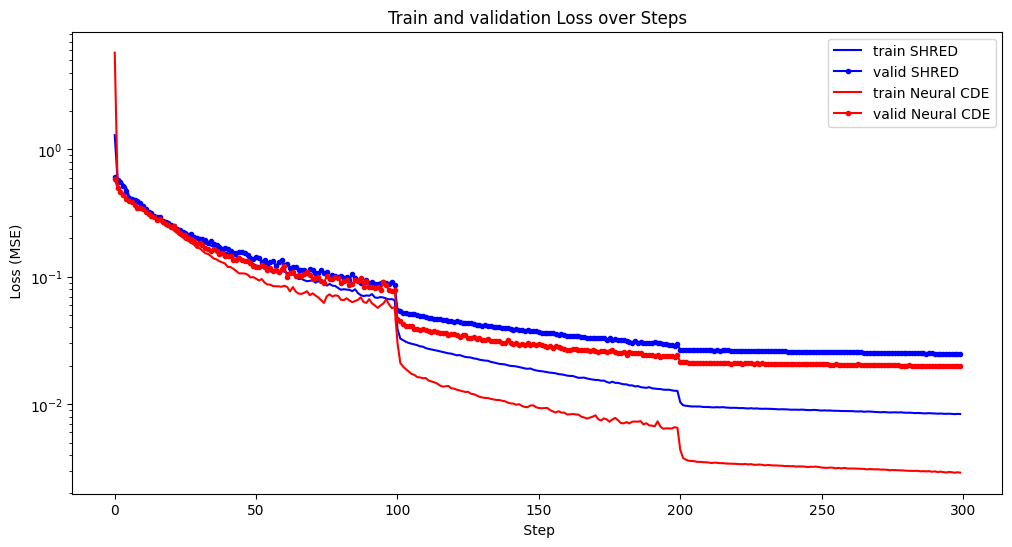

In [19]:
fig, axes = plt.subplots(1, 1, figsize = (12,6))

axes.plot(train_losses_shred, 'b-', label = 'train SHRED')
axes.plot(valid_losses_shred, 'b.-', label = 'valid SHRED')
axes.plot(train_losses_cde, 'r-', label = 'train Neural CDE')
axes.plot(valid_losses_cde, 'r.-', label = 'valid Neural CDE')
axes.legend()
axes.set_yscale('log')
axes.set_xlabel(' Step') 
axes.set_ylabel(' Loss (MSE)')
axes.set_title('Train and validation Loss over Steps')


## Convert Predictions to Physical Space

In [20]:
preds_cde_train = jax.vmap(model_cde)(datasets['cde']['train']['data']['ts'], datasets['cde']['train']['data']['coeffs'])
print(f"CDE train preds shape: {preds_cde_train.shape}")
preds_cde_cf_train = datasets['scaler'].inverse_transform(preds_cde_train)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_cde_il_train = datasets['scaler'].inverse_transform(preds_cde_train)[:, modes_cf:] @ datasets['pod']['il']['V']
print(f"CDE CF train: {preds_cde_cf_train.shape}, IL train: {preds_cde_il_train.shape}")

preds_cde_valid = jax.vmap(model_cde)(datasets['cde']['valid']['data']['ts'],datasets['cde']['valid']['data']['coeffs'])
print(f"CDE valid preds shape: {preds_cde_valid.shape}")
preds_cde_cf_valid = datasets['scaler'].inverse_transform(preds_cde_valid)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_cde_il_valid = datasets['scaler'].inverse_transform(preds_cde_valid)[:, modes_cf:] @ datasets['pod']['il']['V']
print(f"CDE CF valid: {preds_cde_cf_valid.shape}, IL valid: {preds_cde_il_valid.shape}")        

preds_cde_test = jax.vmap(model_cde)(datasets['cde']['test']['data']['ts'],datasets['cde']['test']['data']['coeffs'])
print(f"CDE test preds shape: {preds_cde_test.shape}")
preds_cde_cf_test = datasets['scaler'].inverse_transform(preds_cde_test)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_cde_il_test = datasets['scaler'].inverse_transform(preds_cde_test)[:, modes_cf:] @ datasets['pod']['il']['V']
print(f"CDE CF test: {preds_cde_cf_test.shape}, IL test: {preds_cde_il_test.shape}")        



CDE train preds shape: (3984, 25)
CDE CF train: (3984, 200), IL train: (3984, 200)
CDE valid preds shape: (498, 25)
CDE CF valid: (498, 200), IL valid: (498, 200)
CDE test preds shape: (499, 25)
CDE CF test: (499, 200), IL test: (499, 200)


### CDE Predictions on Second Dataset

In [21]:
preds_shred_train = jax.vmap(model_shred)(datasets['shred']['train']['S_i'])
print(f"SHRED train preds shape: {preds_shred_train.shape}")
preds_shred_cf_train = datasets['scaler'].inverse_transform(preds_shred_train)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_shred_il_train = datasets['scaler'].inverse_transform(preds_shred_train)[:, modes_cf:] @ datasets['pod']['il']['V']
print(f"SHRED CF train: {preds_shred_cf_train.shape}, IL train: {preds_shred_il_train.shape}")

preds_shred_valid = jax.vmap(model_shred)(datasets['shred']['valid']['S_i'])
preds_shred_cf_valid = datasets['scaler'].inverse_transform(preds_shred_valid)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_shred_il_valid = datasets['scaler'].inverse_transform(preds_shred_valid)[:, modes_cf:] @ datasets['pod']['il']['V']

preds_shred_test = jax.vmap(model_shred)(datasets['shred']['test']['S_i'])
preds_shred_cf_test = datasets['scaler'].inverse_transform(preds_shred_test)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_shred_il_test = datasets['scaler'].inverse_transform(preds_shred_test)[:, modes_cf:] @ datasets['pod']['il']['V']
print(f"SHRED CF test: {preds_shred_cf_test.shape}, IL test: {preds_shred_il_test.shape}")



SHRED train preds shape: (3984, 25)
SHRED CF train: (3984, 200), IL train: (3984, 200)
SHRED CF test: (499, 200), IL test: (499, 200)


### SHRED Predictions on Second Dataset

In [22]:
preds_shred_full = jax.vmap(model_shred)(datasets['shred']['sequential']['S_i'])
preds_shred_cf_full = datasets['scaler'].inverse_transform(preds_shred_full)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_shred_il_full = datasets['scaler'].inverse_transform(preds_shred_full)[:, modes_cf:] @ datasets['pod']['il']['V']

preds_cde_full = jax.vmap(model_cde)(datasets['cde']['sequential']['data']['ts'], datasets['cde']['sequential']['data']['coeffs'])
preds_cde_cf_full = datasets['scaler'].inverse_transform(preds_cde_full)[:, :modes_cf] @ datasets['pod']['cf']['V']
preds_cde_il_full = datasets['scaler'].inverse_transform(preds_cde_full)[:, modes_cf:] @ datasets['pod']['il']['V']

x = np.linspace(0, 1, datasets['pod']['cf']['V'].shape[1])

In [23]:
def mse(datapred, datatrue):
    return jnp.mean(jnp.sum((datapred - datatrue)**2, axis = -1))
def rmsre(datapred, datatrue):
    return jnp.mean(jnp.sqrt(jnp.sum((datapred - datatrue)**2, axis = -1))/jnp.sqrt(jnp.sum((datatrue)**2, axis = -1)))

def mae(datapred, datatrue):
    return jnp.mean(jnp.sum(jnp.abs(datapred - datatrue), axis = -1))

def mre(datapred, datatrue):
    return jnp.mean(jnp.abs(datapred - datatrue)) / jnp.mean(jnp.abs(datatrue))


## Metrics and Evaluation

In [24]:
print(f"RMSRE SHRED cf: {rmsre(preds_shred_cf_full, datasets['full_fields']['cf'])}")
print(f"RMSRE SHRED il: {rmsre(preds_shred_il_full, datasets['full_fields']['il'])}")

print(f"RMSRE CDE cf: {rmsre(preds_cde_cf_full, datasets['full_fields']['cf'])}")
print(f"RMSRE CDE il: {rmsre(preds_cde_il_full, datasets['full_fields']['il'])}")

RMSRE SHRED cf: 0.11893129348754883
RMSRE SHRED il: 0.13240504264831543
RMSRE CDE cf: 0.09632213413715363
RMSRE CDE il: 0.1135067269206047


In [25]:
# Log evaluation metrics for both models on full sequence
print("Logging CDE evaluation metrics...")
cde_metrics = log_evaluation_metrics(
    preds_cde_cf_train, preds_cde_cf_valid, preds_cde_cf_test, preds_cde_cf_full,
    preds_cde_il_train, preds_cde_il_valid, preds_cde_il_test, preds_cde_il_full,
    datasets['full_fields']['cf'], datasets['full_fields']['il'],
    model_type="CDE"
)

print("Logging SHRED evaluation metrics...")
shred_metrics = log_evaluation_metrics(
    preds_shred_cf_train, preds_shred_cf_valid, preds_shred_cf_test, preds_shred_cf_full,
    preds_shred_il_train, preds_shred_il_valid, preds_shred_il_test, preds_shred_il_full,
    datasets['full_fields']['cf'], datasets['full_fields']['il'],
    model_type="SHRED"
)

# Log split-wise metrics for CDE (in POD coefficient space)
log_split_metrics(
    preds_cde_train[:, :modes_cf], preds_cde_valid[:, :modes_cf], preds_cde_test[:, :modes_cf],
    preds_cde_train[:, modes_cf:], preds_cde_valid[:, modes_cf:], preds_cde_test[:, modes_cf:],
    datasets['cde']['train']['data']['Y'][:, :modes_cf],
    datasets['cde']['valid']['data']['Y'][:, :modes_cf],
    datasets['cde']['test']['data']['Y'][:, :modes_cf],
    datasets['cde']['train']['data']['Y'][:, modes_cf:],
    datasets['cde']['valid']['data']['Y'][:, modes_cf:],
    datasets['cde']['test']['data']['Y'][:, modes_cf:],
    model_type="CDE"
)

# Log comparison metrics
log_comparison_metrics(cde_metrics, shred_metrics)

print('RMSE SHRED CF: {:.6f} | SHRED IL: {:.6f}'.format(rmsre(preds_shred_cf_full, datasets['full_fields']['cf']), rmsre(preds_shred_il_full, datasets['full_fields']['il'])))
print('RMSE CDE  CF: {:.6f} | CDE   IL: {:.6f}'.format(rmsre(preds_cde_cf_full, datasets['full_fields']['cf']), rmsre(preds_cde_il_full, datasets['full_fields']['il'])))

Logging CDE evaluation metrics...
Logging SHRED evaluation metrics...
RMSE SHRED CF: 0.118931 | SHRED IL: 0.132405
RMSE CDE  CF: 0.096322 | CDE   IL: 0.113507


### Model Performance Summary

In [26]:
datasets['shred']['sequential']['sensors_raw'].shape, preds_shred_cf_full.shape, preds_cde_cf_full.shape,datasets['full_fields']['cf'].shape, x.shape

((4981, 10, 6), (4981, 200), (4981, 200), (4981, 200), (200,))

## Visualization and Animations

### Animations - Cross-Flow (CF)

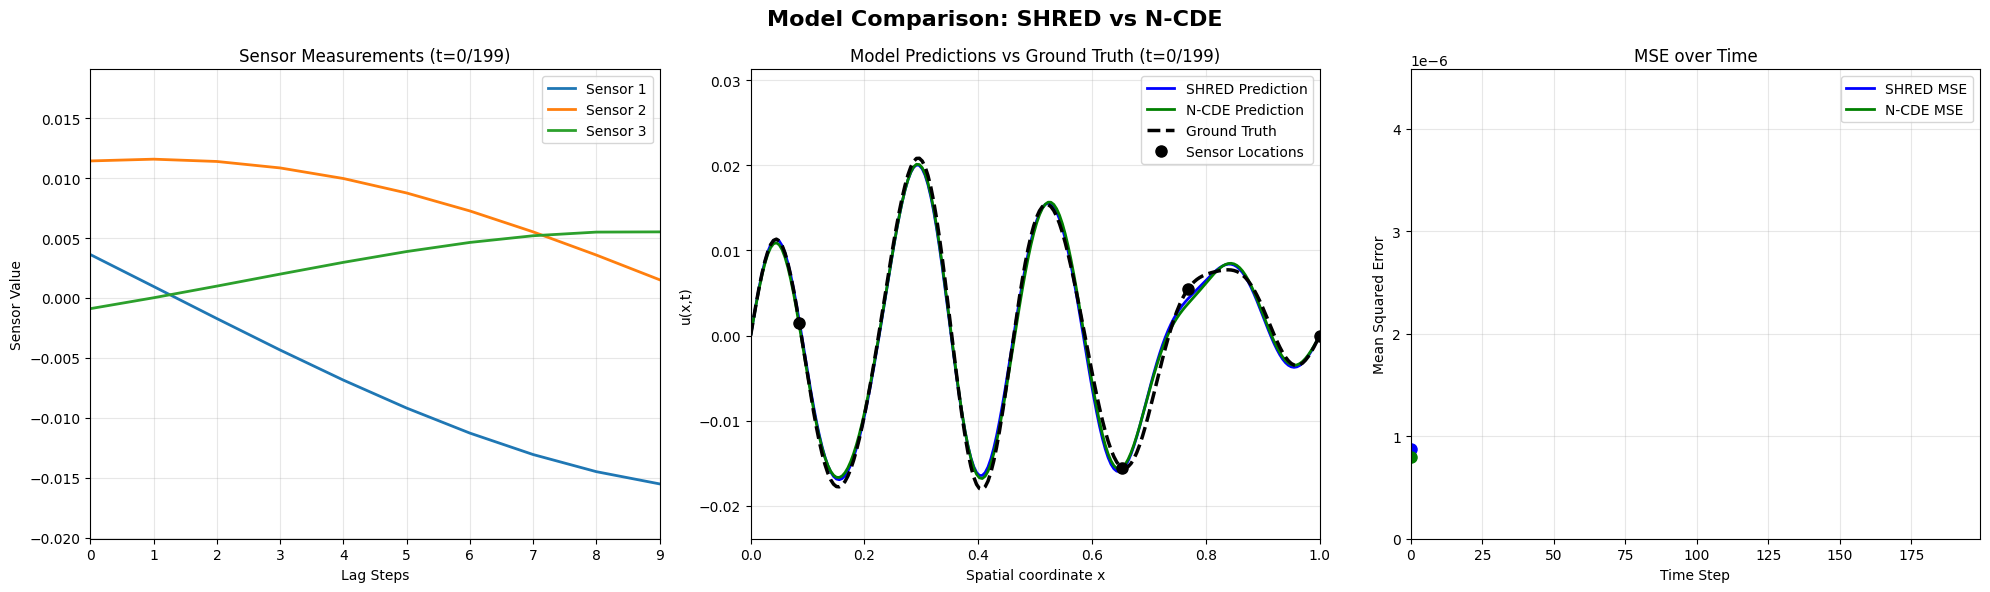

PosixPath('cf_comparison.gif')

In [27]:
idx = np.random.randint(0, datasets['shred']['sequential']['S_i'].shape[0]-200)
plot_steps = 200
save_comparison_gif(x, datasets['shred']['sequential']['sensors_raw'][idx:idx+plot_steps, :, :nsensors], preds_shred_cf_full[idx:idx+plot_steps], preds_cde_cf_full[idx:idx+plot_steps],datasets['full_fields']['cf'][idx:idx+plot_steps], datasets['sensor_locations'],  'cf_comparison.gif')

### Animations - In-Line (IL)

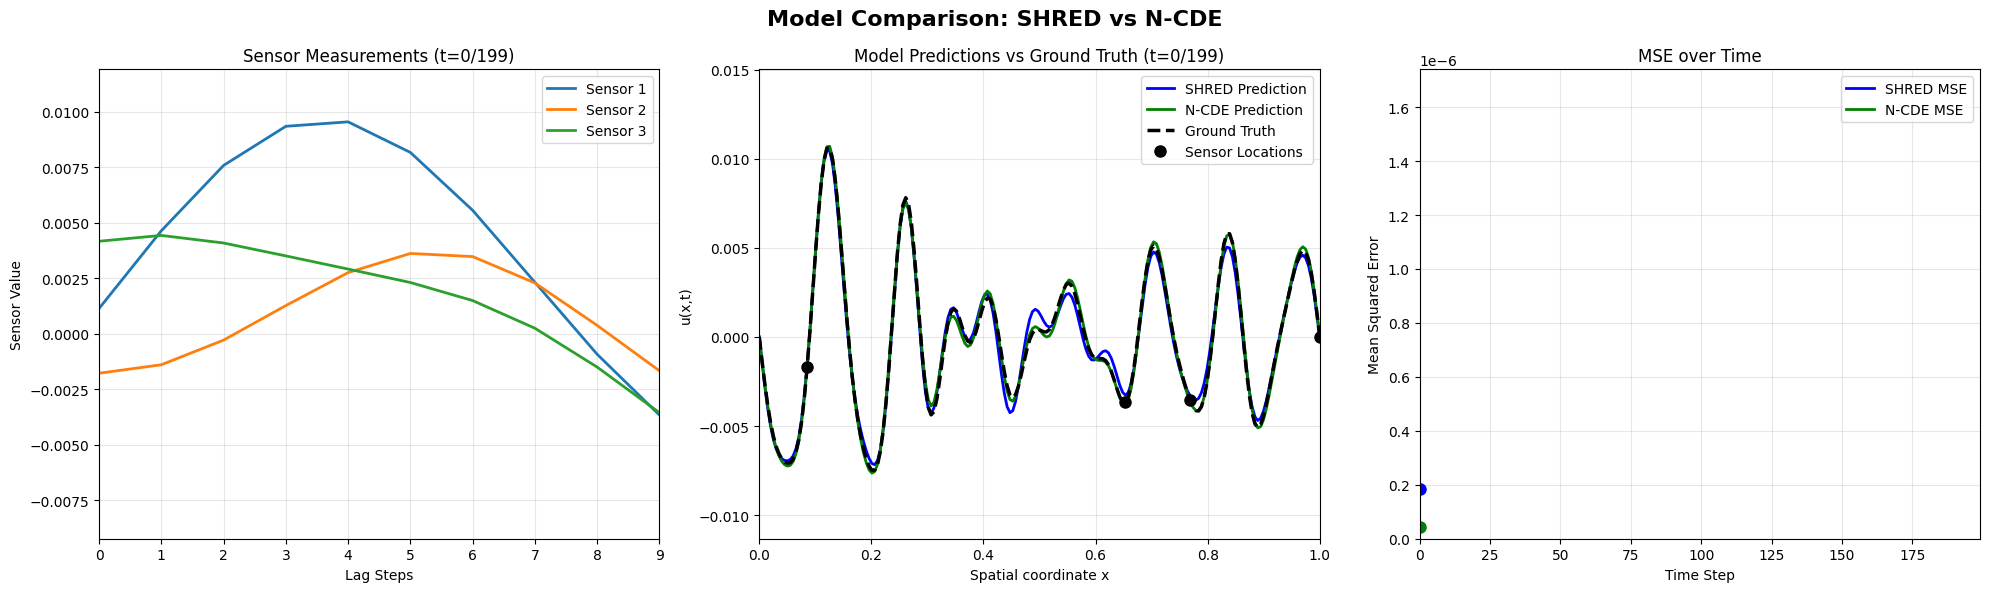

PosixPath('il_comparison.gif')

In [28]:
idx = np.random.randint(0, datasets['shred']['sequential']['S_i'].shape[0]-200)
plot_steps = 200
save_comparison_gif(x, datasets['shred']['sequential']['sensors_raw'][idx:idx+plot_steps, :, nsensors:], preds_shred_il_full[idx:idx+plot_steps], preds_cde_il_full[idx:idx+plot_steps],datasets['full_fields']['il'][idx:idx+plot_steps], datasets['sensor_locations'],  'il_comparison.gif')

## Evaluation on Unseen Data (Held-Out Pair)

In [29]:
# Load unseen test pair and process with TRAINING POD basis & scaler
cf_unseen, il_unseen = extract_dataframe(test_pair[0], test_pair[1], stride=5, transpose=True)
min_len = min(cf_unseen.shape[0], il_unseen.shape[0])
cf_unseen, il_unseen = cf_unseen[:min_len], il_unseen[:min_len]
print(f"Unseen pair: {test_pair[0].name} | {test_pair[1].name}")
print(f"Shape: cf={cf_unseen.shape}, il={il_unseen.shape}")

# Create sequences with same lag and sensor locations as training
seq_cf_u = create_sequences(cf_unseen, lag, add_time=True)
seq_il_u = create_sequences(il_unseen, lag, add_time=True)

X_cf_u = seq_cf_u[:, :, datasets['sensor_locations']]
Y_cf_u = seq_cf_u[:, -1, :-1]
X_il_u = seq_il_u[:, :, datasets['sensor_locations']]
Y_il_u = seq_il_u[:, -1, :-1]

# Project with training POD basis and scale with training scaler
V_cf = datasets['pod']['cf']['V']
V_il = datasets['pod']['il']['V']
pod_cf_u = Y_cf_u @ V_cf.T
pod_il_u = Y_il_u @ V_il.T
pod_unseen = np.concatenate([pod_cf_u, pod_il_u], axis=-1)
pod_unseen_scaled = datasets['scaler'].transform(pod_unseen)

# Build CDE inputs
X_unseen = np.concatenate([X_cf_u[:, :, :-1], X_il_u], axis=-1)
unseen_data_cde, _ = prepare_data_CDE(X_unseen, pod_unseen_scaled)

print(f"Unseen windows: {X_unseen.shape[0]}")
print(f"Sensor input shape: {X_unseen.shape}, POD target shape: {pod_unseen_scaled.shape}")

Unseen pair: DISPL2160_DISPLCF.csv | DISPL2160_DISPLIL.csv
Shape: cf=(2946, 200), il=(2946, 200)
Unseen windows: 2937
Sensor input shape: (2937, 10, 7), POD target shape: (2937, 25)


In [30]:
# CDE predictions on unseen data
preds_cde_unseen = jax.vmap(model_cde)(unseen_data_cde['ts'], unseen_data_cde['coeffs'])
preds_cde_cf_unseen = datasets['scaler'].inverse_transform(preds_cde_unseen)[:, :modes_cf] @ V_cf
preds_cde_il_unseen = datasets['scaler'].inverse_transform(preds_cde_unseen)[:, modes_cf:] @ V_il
print(f"CDE unseen preds: CF {preds_cde_cf_unseen.shape}, IL {preds_cde_il_unseen.shape}")

# SHRED predictions on unseen data
S_i_unseen = X_unseen[:, :, :-1]
preds_shred_unseen = jax.vmap(model_shred)(S_i_unseen)
preds_shred_cf_unseen = datasets['scaler'].inverse_transform(preds_shred_unseen)[:, :modes_cf] @ V_cf
preds_shred_il_unseen = datasets['scaler'].inverse_transform(preds_shred_unseen)[:, modes_cf:] @ V_il
print(f"SHRED unseen preds: CF {preds_shred_cf_unseen.shape}, IL {preds_shred_il_unseen.shape}")

CDE unseen preds: CF (2937, 200), IL (2937, 200)
SHRED unseen preds: CF (2937, 200), IL (2937, 200)


In [31]:
# Metrics on unseen data
print("=== Unseen Data Metrics ===")
print(f"RMSRE CDE   CF: {rmsre(preds_cde_cf_unseen, Y_cf_u):.6f}")
print(f"RMSRE CDE   IL: {rmsre(preds_cde_il_unseen, Y_il_u):.6f}")
print(f"RMSRE SHRED CF: {rmsre(preds_shred_cf_unseen, Y_cf_u):.6f}")
print(f"RMSRE SHRED IL: {rmsre(preds_shred_il_unseen, Y_il_u):.6f}")
print()
print("=== Training Data Metrics (for comparison) ===")
print(f"RMSRE CDE   CF: {rmsre(preds_cde_cf_full, datasets['full_fields']['cf']):.6f}")
print(f"RMSRE CDE   IL: {rmsre(preds_cde_il_full, datasets['full_fields']['il']):.6f}")
print(f"RMSRE SHRED CF: {rmsre(preds_shred_cf_full, datasets['full_fields']['cf']):.6f}")
print(f"RMSRE SHRED IL: {rmsre(preds_shred_il_full, datasets['full_fields']['il']):.6f}")

=== Unseen Data Metrics ===
RMSRE CDE   CF: 2.383224
RMSRE CDE   IL: 2.689507
RMSRE SHRED CF: 1.524809
RMSRE SHRED IL: 1.617613

=== Training Data Metrics (for comparison) ===
RMSRE CDE   CF: 0.096322
RMSRE CDE   IL: 0.113507
RMSRE SHRED CF: 0.118931
RMSRE SHRED IL: 0.132405


### Animations - Unseen Data (CF)

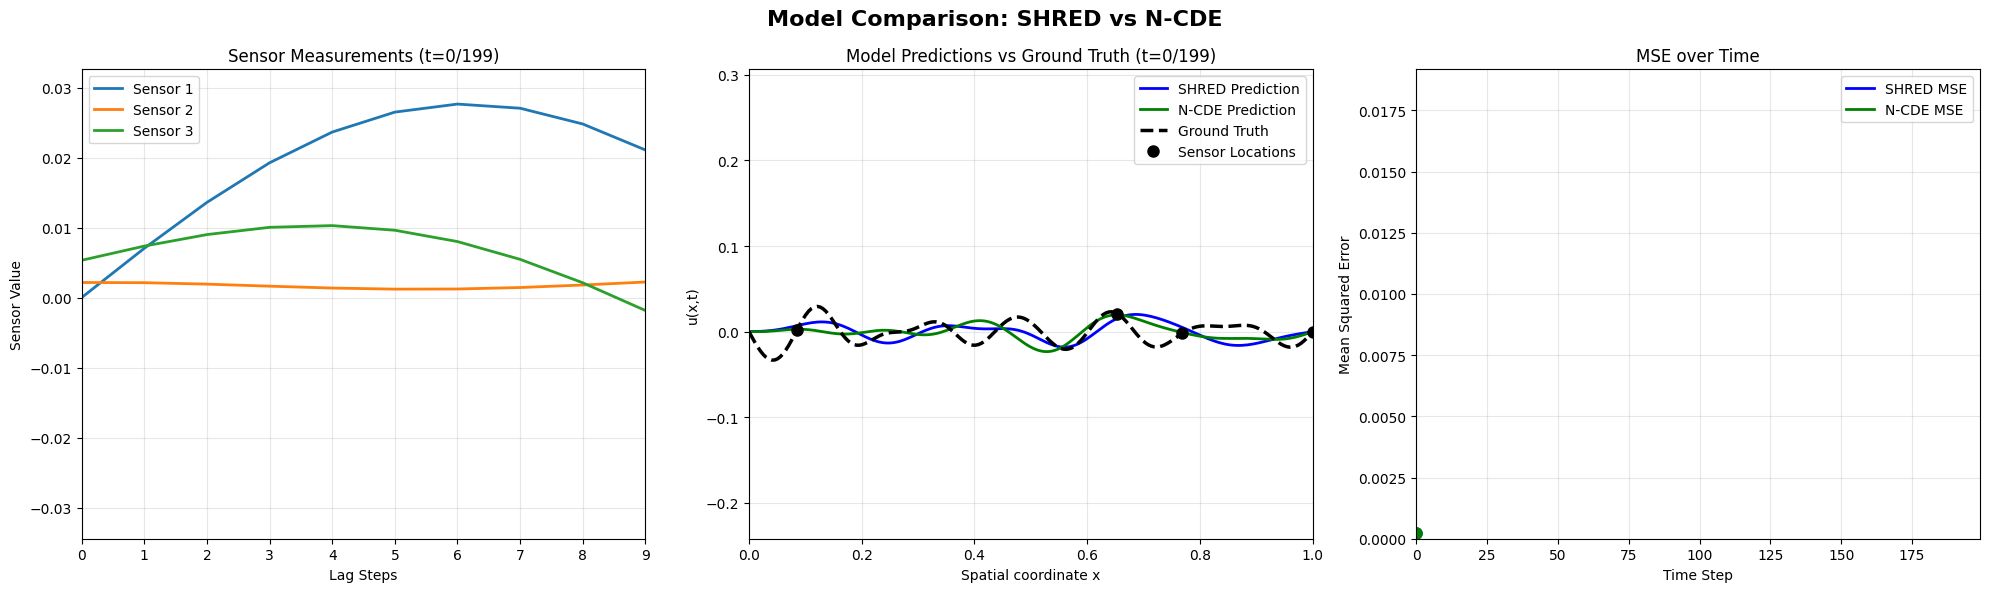

PosixPath('cf_comparison_unseen.gif')

In [32]:
x_unseen = np.linspace(0, 1, V_cf.shape[1])
sensors_unseen = X_unseen[:, :, :-1]

idx = np.random.randint(0, sensors_unseen.shape[0] - 200)
plot_steps = 200
save_comparison_gif(x_unseen, sensors_unseen[idx:idx+plot_steps, :, :nsensors], preds_shred_cf_unseen[idx:idx+plot_steps], preds_cde_cf_unseen[idx:idx+plot_steps], Y_cf_u[idx:idx+plot_steps], datasets['sensor_locations'], 'cf_comparison_unseen.gif')

### Animations - Unseen Data (IL)

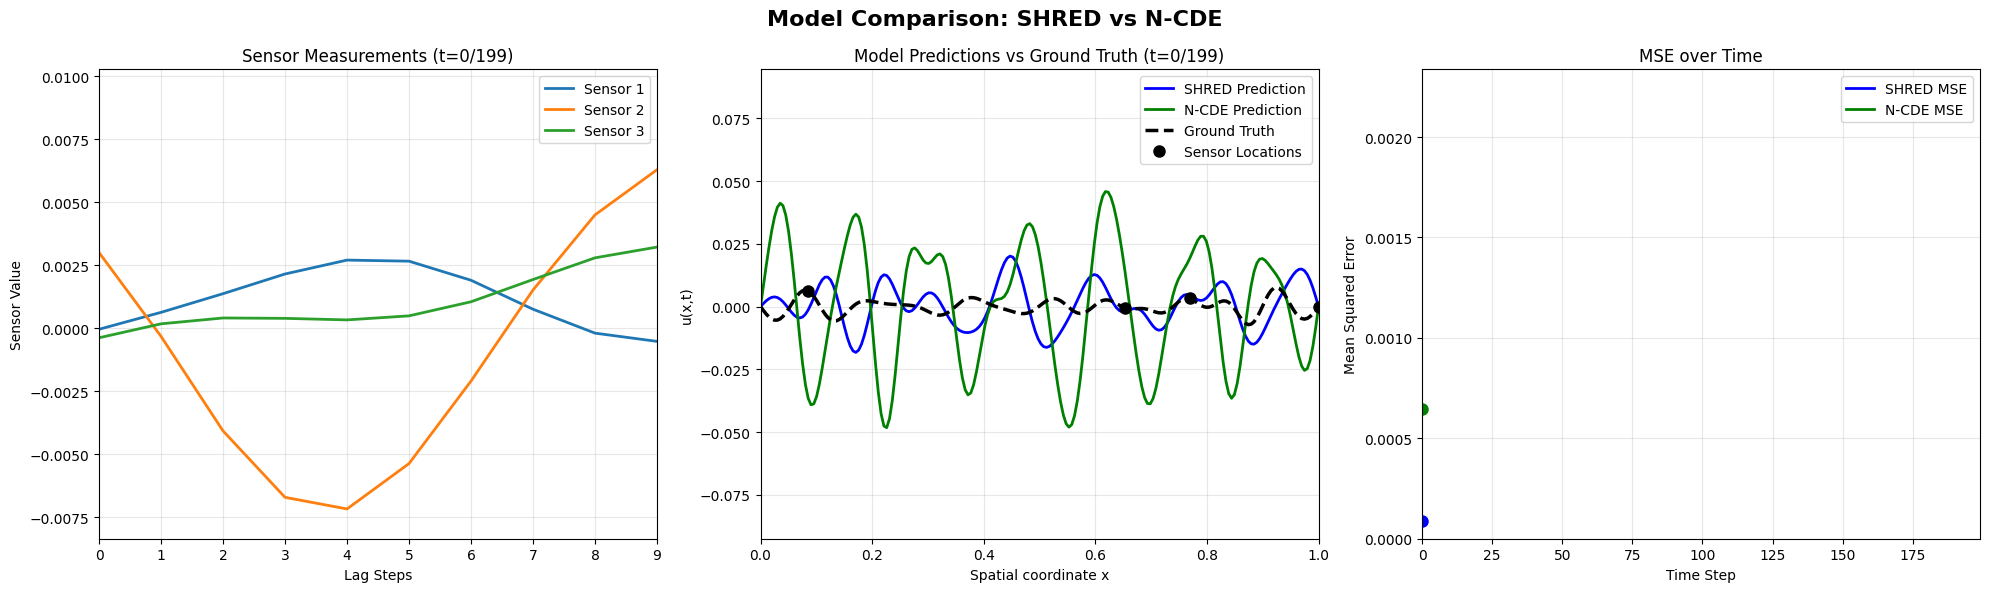

PosixPath('il_comparison_unseen.gif')

In [33]:
idx = np.random.randint(0, sensors_unseen.shape[0] - 200)
plot_steps = 200
save_comparison_gif(x_unseen, sensors_unseen[idx:idx+plot_steps, :, nsensors:], preds_shred_il_unseen[idx:idx+plot_steps], preds_cde_il_unseen[idx:idx+plot_steps], Y_il_u[idx:idx+plot_steps], datasets['sensor_locations'], 'il_comparison_unseen.gif')

In [34]:
# End MLflow run
end_run()
print(f"MLflow run '{run_name}' completed and logged to 'mlruns/' directory")

MLflow run '2026-02-10_v13' completed and logged to 'mlruns/' directory
